## Sequence Construction Pipeline

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('../data/spotify_tracks.csv')

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
mood_features = [
    'energy',
    'valence',
    'danceability',
    'acousticness',
    'tempo'
]

### Normalize

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[mood_features] = scaler.fit_transform(df[mood_features])

In [5]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.686294,0.4610,1,-6.746,0,0.1430,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.426396,0.1660,1,-17.235,1,0.0763,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.444670,0.3590,0,-9.734,1,0.0557,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.270051,0.0596,0,-18.515,1,0.0363,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.627411,0.4430,2,-9.681,1,0.0526,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic


Using elbow method to decide total numebr of clusters.

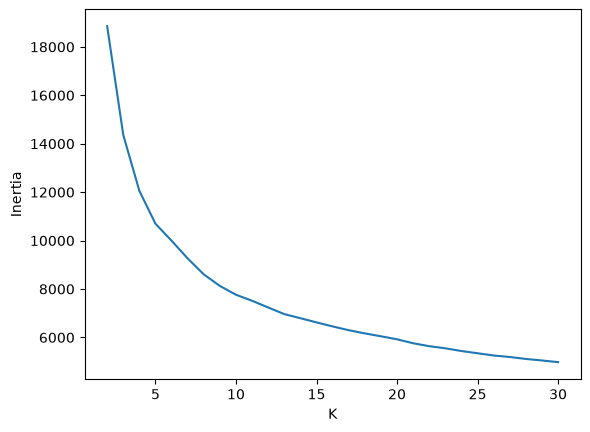

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 31):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )
    
    km.fit(df[mood_features])
    
    inertia.append(km.inertia_)

plt.plot(range(2,31), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

Use Silhoutte Score to dcide the number of clusters. The the K with the highest score

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 21):
    
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )
    
    labels = km.fit_predict(df[mood_features])
    
    score = silhouette_score(df[mood_features], labels)
    
    scores.append(score)

KeyboardInterrupt: 

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(
    df[mood_features]
)

In [7]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.686294,0.4610,1,...,0,0.1430,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic,7
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.426396,0.1660,1,...,1,0.0763,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic,6
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.444670,0.3590,0,...,1,0.0557,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic,5
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.270051,0.0596,0,...,1,0.0363,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic,6
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.627411,0.4430,2,...,1,0.0526,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic,5


### Sequence Construction

In [11]:
import random
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

In [12]:
def find_next_track(
    current_vector,
    candidate_vectors,
    candidate_indices,
    max_distance=0.15
):
    """
    Find nearest neighbor within distance threshold.

    Parameters
    ----------
    current_vector : np.array
    candidate_vectors : np.array
    candidate_indices : list
    max_distance : float

    Returns
    -------
    next_index, distance
    """

    distances = cdist(
        [current_vector],
        candidate_vectors,
        metric='euclidean'
    )[0]

    sorted_positions = np.argsort(distances)

    for pos in sorted_positions:

        if distances[pos] <= max_distance:
            return candidate_indices[pos], distances[pos]

    return None, None

In [13]:
def generate_single_sequence(
    genre_df,
    sequence_length=6,
    max_distance=0.15
):
    """
    Generate one smooth sequence from a genre.
    """

    if len(genre_df) < sequence_length:
        return None

    remaining_df = genre_df.copy()

    # random starting track
    start_row = remaining_df.sample(1)

    current_idx = start_row.index[0]

    sequence = [current_idx]

    remaining_df = remaining_df.drop(current_idx)

    while len(sequence) < sequence_length:

        current_vector = (
            genre_df.loc[current_idx, mood_features]
            .values
        )

        candidate_vectors = (
            remaining_df[mood_features]
            .values
        )

        candidate_indices = (
            remaining_df.index.tolist()
        )

        next_idx, distance = find_next_track(
            current_vector,
            candidate_vectors,
            candidate_indices,
            max_distance=max_distance
        )

        if next_idx is None:
            break

        sequence.append(next_idx)

        remaining_df = remaining_df.drop(next_idx)

        current_idx = next_idx

    if len(sequence) == sequence_length:
        return sequence

    return None

In [14]:
def generate_sequences_for_genre(
    genre_df,
    n_sequences=100,
    min_length=5,
    max_length=8,
    distance_threshold=0.15
):
    """
    Generate many smooth sequences for a single genre.
    """

    sequences = []

    attempts = 0
    max_attempts = n_sequences * 20

    while (
        len(sequences) < n_sequences
        and attempts < max_attempts
    ):

        seq_length = random.randint(
            min_length,
            max_length
        )

        seq = generate_single_sequence(
            genre_df,
            sequence_length=seq_length,
            max_distance=distance_threshold
        )

        if seq is not None:
            sequences.append(seq)

        attempts += 1

    return sequences

### Generate Sequences For Entire Dataset

In [15]:
genre_column = "track_genre"

In [19]:
all_sequences = []

genres = df["track_genre"].unique()

for genre in genres:

    genre_df = df[
        df["track_genre"] == genre
    ].copy()

    genre_sequences = generate_sequences_for_genre(
        genre_df,
        n_sequences=25,
        min_length=8,
        max_length=8,
        distance_threshold=0.15
    )

    all_sequences.extend(genre_sequences)

print(f"Total sequences: {len(all_sequences)}")

Total sequences: 2850


In [20]:
all_sequences[0:10]

[[168, 835, 959, 500, 1, 36, 87, 88],
 [170, 179, 629, 551, 944, 193, 62, 601],
 [274, 393, 369, 863, 336, 657, 282, 271],
 [281, 380, 187, 814, 790, 588, 105, 68],
 [917, 506, 567, 503, 236, 736, 252, 64],
 [626, 714, 646, 271, 282, 657, 210, 829],
 [49, 498, 42, 43, 47, 46, 48, 45],
 [453, 235, 458, 331, 194, 164, 6, 22],
 [566, 289, 630, 376, 257, 551, 179, 629],
 [718, 464, 594, 509, 530, 267, 153, 934]]

## Sequence Extraction for Training

In [33]:
fs = (
    df.loc[all_sequences[0], mood_features].values
)

X = fs[:-1]
y = fs[-1]

print("fs:", fs)
print("X:", X)
print("y:", y)

fs: [[0.126      0.28040201 0.48629442 0.96987952 0.39580149]
 [0.124      0.25829146 0.4964467  0.95582329 0.37549924]
 [0.0812     0.24422111 0.43248731 0.95180723 0.35009779]
 [0.114      0.27035176 0.39086294 0.92068273 0.38342126]
 [0.166      0.26834171 0.42639594 0.92771084 0.31839735]
 [0.153      0.18090452 0.41522843 0.94277108 0.35033611]
 [0.153      0.18090452 0.41522843 0.94277108 0.35033611]
 [0.153      0.18090452 0.41522843 0.94277108 0.35033611]]
X: [[0.126      0.28040201 0.48629442 0.96987952 0.39580149]
 [0.124      0.25829146 0.4964467  0.95582329 0.37549924]
 [0.0812     0.24422111 0.43248731 0.95180723 0.35009779]
 [0.114      0.27035176 0.39086294 0.92068273 0.38342126]
 [0.166      0.26834171 0.42639594 0.92771084 0.31839735]
 [0.153      0.18090452 0.41522843 0.94277108 0.35033611]
 [0.153      0.18090452 0.41522843 0.94277108 0.35033611]]
y: [0.153      0.18090452 0.41522843 0.94277108 0.35033611]


### Convert Sequences Into LSTM Training Data

In [21]:
X = []
y = []

for seq in all_sequences:

    feature_sequence = (
        df.loc[seq, mood_features]
        .values
    )

    X.append(feature_sequence[:-1])

    y.append(feature_sequence[-1])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2850, 7, 5)
(2850, 5)


### Sequence Quality Check

Before training, compute average step distance.

In [22]:
def sequence_smoothness(
    sequence_features
):
    distances = []

    for i in range(
        len(sequence_features) - 1
    ):

        d = np.linalg.norm(
            sequence_features[i+1]
            - sequence_features[i]
        )

        distances.append(d)

    return np.mean(distances)

### Evaluate

In [23]:
scores = []

for seq in all_sequences[:100]:

    features = (
        df.loc[seq, mood_features]
        .values
    )

    scores.append(
        sequence_smoothness(features)
    )

print(
    f"Average smoothness: {np.mean(scores):.4f}"
)

Average smoothness: 0.0621


### Save sequences to file for later training

#### Option 1 : Save Raw Sequence

In [35]:
import json

with open("../data/sequences.json", "w") as f:
    json.dump(all_sequences, f)

In [37]:
import json

with open("../data/sequences.json", "r") as f:
    all_sequences_loaded = json.load(f)

#### Option 2 : Save as Pickle

In [40]:
import pickle

with open("../data/sequences.pkl", "wb") as f:
    pickle.dump(all_sequences, f)

In [41]:
with open("../data/sequences.pkl", "rb") as f:
    all_sequences_loaded = pickle.load(f)

#### Option 3 : Save Training Arrays Directly

In [42]:
np.save("../data/X.npy", X)
np.save("../data/y.npy", y)

In [44]:
X = np.load("../data/X.npy")
y = np.load("../data/y.npy")

print(X.shape)
print(y.shape)

(7, 5)
(5,)


#### Option 4: Save everything in One File

In [46]:
np.savez_compressed(
    "../data/training_sequences.npz",
    X=X,
    y=y
)

In [47]:
data = np.load("../data/training_sequences.npz")

X = data["X"]
y = data["y"]